# PEL 309 - Data Science - Paper

Esse arquivo contém as análises e experimentos correspondentes ao trabalho da matéria PEL 309.

## EDA - Exploração dos dados

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("./data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [3]:
df.isnull().sum() ## removing addiction level

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

### Droping Obvious columns

O problema não é uma série, logo podemos remover os ids

In [4]:
df = df.drop(columns=['transaction_id', 'user_id']) 

In [5]:
# Converting categorical columns to categorical data type
for column in ["gender", "stress_level", "academic_work_impact", "addiction_level"]:
    df[column] = df[column].astype("category")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   age                      7500 non-null   int64   
 1   gender                   7500 non-null   category
 2   daily_screen_time_hours  7500 non-null   float64 
 3   social_media_hours       7500 non-null   float64 
 4   gaming_hours             7500 non-null   float64 
 5   work_study_hours         7500 non-null   float64 
 6   sleep_hours              7500 non-null   float64 
 7   notifications_per_day    7500 non-null   int64   
 8   app_opens_per_day        7500 non-null   int64   
 9   weekend_screen_time      7500 non-null   float64 
 10  stress_level             7500 non-null   category
 11  academic_work_impact     7500 non-null   category
 12  addiction_level          6681 non-null   category
 13  addicted_label           7500 non-null   int64   
dtypes: category(4), flo

In [7]:
### Removing inconsistencies
# More time on social media than screen time. Also I created a ratio to validate a hypotesis.

display(df[df['social_media_hours'] > df['daily_screen_time_hours']].head())

df = df[df['social_media_hours'] <= df['daily_screen_time_hours']]

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
7,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
23,34,Female,3.07,4.99,1.20,4.15,8.73,54,82,3.86,Low,Yes,Severe,1
56,35,Male,5.63,5.69,2.55,4.64,4.96,23,161,6.84,Medium,No,Severe,1
58,25,Female,4.07,4.70,2.43,4.85,5.52,153,112,5.70,Medium,No,Severe,1
65,33,Female,5.59,5.70,3.25,3.53,6.55,100,79,6.90,Medium,Yes,Severe,1


### Distribuição das categorias

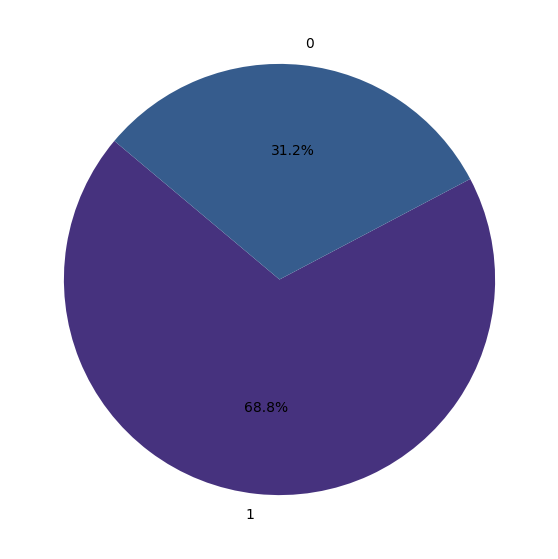

In [8]:
# Calculando a contagem de cada label
label_counts = df['addicted_label'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))

#plt.title('Proporção por Categoria de Vício')
plt.viridis()
plt.show()

/tmp/ipykernel_17061/1634705495.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='addicted_label', palette='viridis', order=df['addicted_label'].value_counts().index[::-1])


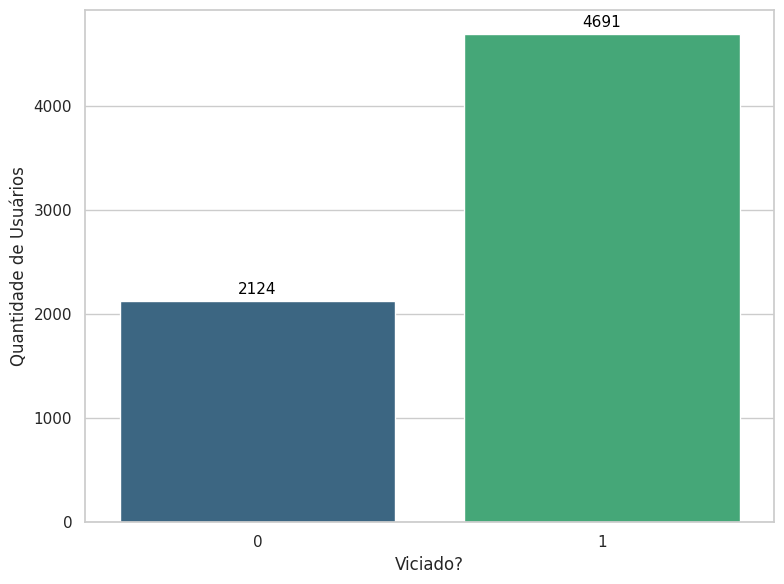

In [9]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x='addicted_label', palette='viridis', order=df['addicted_label'].value_counts().index[::-1])

# Adicionando o título e rótulos
#plt.title('Distribuição de categorias', fontsize=15)
plt.xlabel('Viciado?', fontsize=12)
plt.ylabel('Quantidade de Usuários', fontsize=12)

# Dica: Adicionar os valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()

# Correlation study

<Axes: xlabel='addicted_label', ylabel='daily_screen_time_hours'>

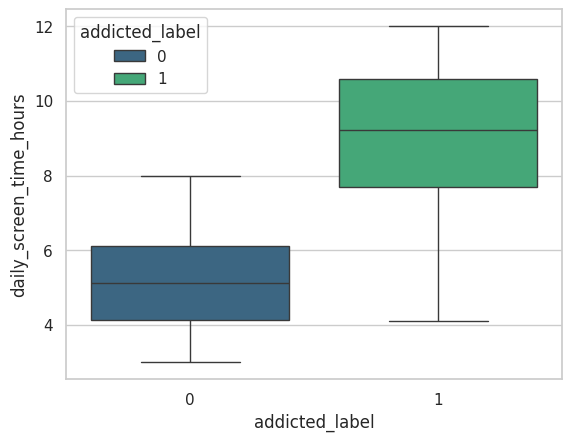

In [10]:
sns.boxplot(data=df, x='addicted_label', y='daily_screen_time_hours', hue="addicted_label", showfliers=True, palette='viridis')

<Axes: xlabel='addicted_label', ylabel='weekend_screen_time'>

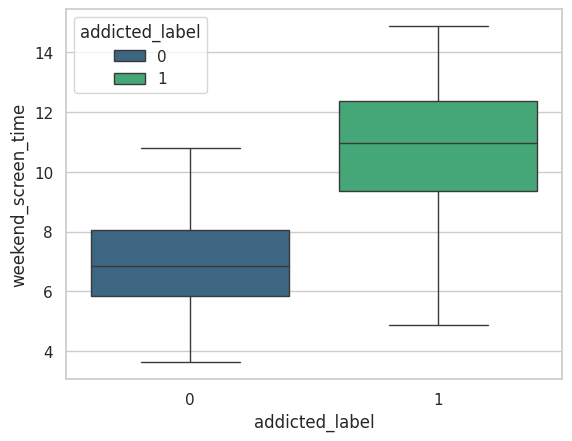

In [11]:
sns.boxplot(data=df, x='addicted_label', y='weekend_screen_time', hue="addicted_label", showfliers=True, palette='viridis')

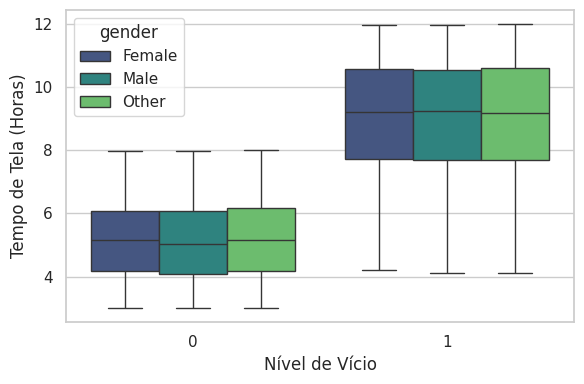

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='addicted_label', y='daily_screen_time_hours', hue='gender', palette='viridis')

#plt.title('Impacto do Gênero e Tempo de Tela no Nível de Vício')
plt.xlabel('Nível de Vício')
plt.ylabel('Tempo de Tela (Horas)')

plt.tight_layout()

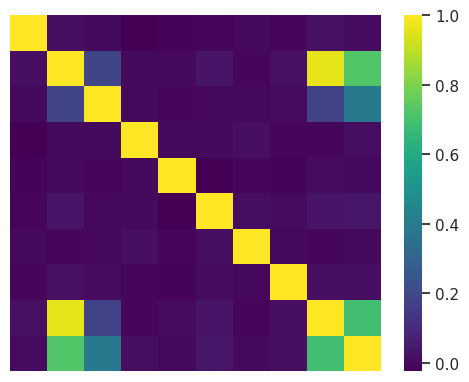

In [13]:
plt.figure(figsize=(5, 4))

pear_correl = df.corr(method="pearson", numeric_only=True)

sns.heatmap(pear_correl, cmap="viridis", xticklabels=False, yticklabels=False)

plt.tight_layout()

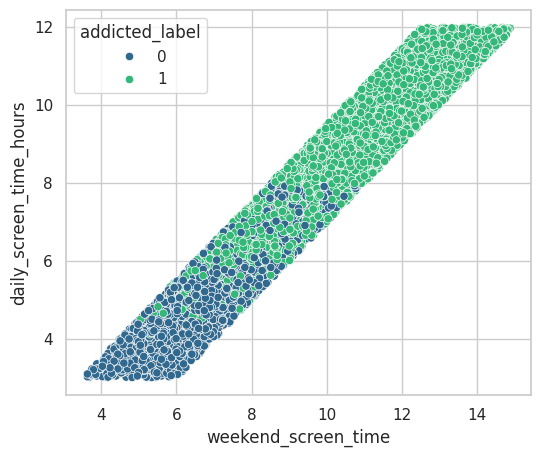

In [14]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="weekend_screen_time", y="daily_screen_time_hours", palette='viridis', hue="addicted_label")
#plt.title("Scatterplot: Tempo de tela diário vs tempo no fim de semana")
plt.show()

## Criação de features

Tive umas boas ideias!

#### Removing Unused/Bad Columns

Depois de justificarmos a remoção e criação de novas colunas durante a análise exploratória, vamos deletar algumas colunas

In [15]:
df.head(5)

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


### Removing gender after EDA and visualization analysis

In [16]:
df = df.drop(columns=['addiction_level', 'weekend_screen_time', 'gender'])  

In [17]:
df["screen_time_to_social_network_ratio"] = df["social_media_hours"]/df["daily_screen_time_hours"]

In [18]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,addicted_label,screen_time_to_social_network_ratio
count,6815.000000,6815.000000,6815.000000,6815.000000,6815.000000,6815.000000,6815.000000,6815.000000,6815.000000,6815.000000
mean,26.575642,7.853787,3.096657,2.015034,3.240411,6.730430,134.594571,98.129274,0.688335,0.425739
std,5.207871,2.463519,1.541269,1.146392,1.597977,1.283223,66.577836,48.475556,0.463208,0.230451
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,0.000000,0.042808
25%,22.000000,5.820000,1.770000,1.010000,1.850000,5.630000,76.000000,56.000000,0.000000,0.237125
50%,27.000000,7.930000,3.010000,2.040000,3.210000,6.710000,135.000000,99.000000,1.000000,0.404020
75%,31.000000,10.010000,4.370000,2.990000,4.640000,7.840000,192.000000,140.000000,1.000000,0.579840
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,1.000000,1.000000


In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 6815 entries, 0 to 7499
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   age                                  6815 non-null   int64   
 1   daily_screen_time_hours              6815 non-null   float64 
 2   social_media_hours                   6815 non-null   float64 
 3   gaming_hours                         6815 non-null   float64 
 4   work_study_hours                     6815 non-null   float64 
 5   sleep_hours                          6815 non-null   float64 
 6   notifications_per_day                6815 non-null   int64   
 7   app_opens_per_day                    6815 non-null   int64   
 8   stress_level                         6815 non-null   category
 9   academic_work_impact                 6815 non-null   category
 10  addicted_label                       6815 non-null   int64   
 11  screen_time_to_social_network_rat

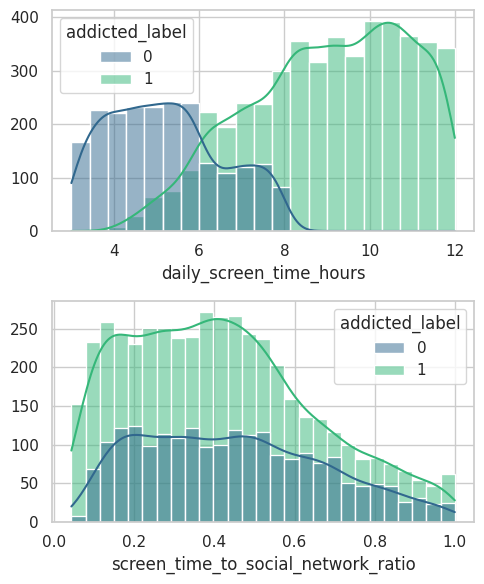

In [20]:
f, axes = plt.subplots(2, 1, figsize=(5, 6))

sns.histplot(df, x="daily_screen_time_hours", kde=True, ax=axes[0], palette='viridis', hue="addicted_label")
#ax.set_title("Histograma + KDE: Tempo de Tela diário")

axes[0].set_ylabel("")

sns.histplot(df, x="screen_time_to_social_network_ratio", kde=True, ax=axes[1], hue="addicted_label", palette='viridis')
#ax.set_title("Distribuição da Razão por Classe de Vício")

axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [21]:
pear_correl = df.corr(method="pearson", numeric_only=True)
pear_correl

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,addicted_label,screen_time_to_social_network_ratio
age,1.000000,0.013004,0.002537,-0.023850,-0.014054,-0.008395,0.001485,-0.003955,0.006185,-0.006324
daily_screen_time_hours,0.013004,1.000000,0.186843,0.000606,0.003896,0.031515,-0.005452,0.018664,0.720570,-0.435144
social_media_hours,0.002537,0.186843,1.000000,0.001340,-0.006745,-0.001131,-0.001499,0.006494,0.389243,0.750659
gaming_hours,-0.023850,0.000606,0.001340,1.000000,0.001753,0.002199,0.012964,-0.009883,0.010699,0.002118
work_study_hours,-0.014054,0.003896,-0.006745,0.001753,1.000000,-0.020569,-0.011797,-0.013342,-0.001937,-0.018113
sleep_hours,-0.008395,0.031515,-0.001131,0.002199,-0.020569,1.000000,0.011012,0.005019,0.032379,-0.016511
notifications_per_day,0.001485,-0.005452,-0.001499,0.012964,-0.011797,0.011012,1.000000,-0.000441,0.003559,0.004916
app_opens_per_day,-0.003955,0.018664,0.006494,-0.009883,-0.013342,0.005019,-0.000441,1.000000,0.015435,-0.010285
addicted_label,0.006185,0.720570,0.389243,0.010699,-0.001937,0.032379,0.003559,0.015435,1.000000,-0.065784
screen_time_to_social_network_ratio,-0.006324,-0.435144,0.750659,0.002118,-0.018113,-0.016511,0.004916,-0.010285,-0.065784,1.000000


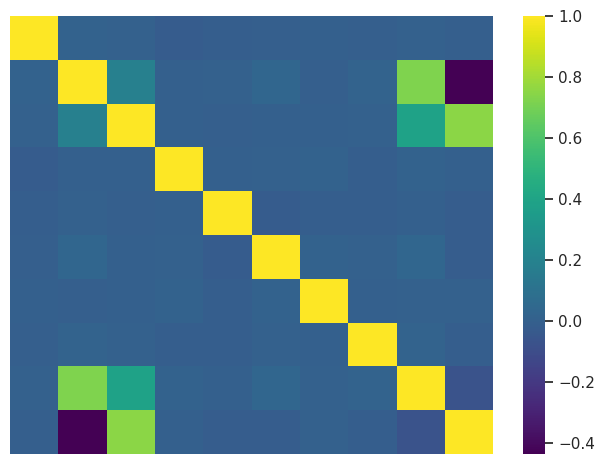

In [22]:
sns.heatmap(pear_correl, cmap="viridis", xticklabels=False, yticklabels=False)

plt.tight_layout()

<Axes: xlabel='daily_screen_time_hours', ylabel='social_media_hours'>

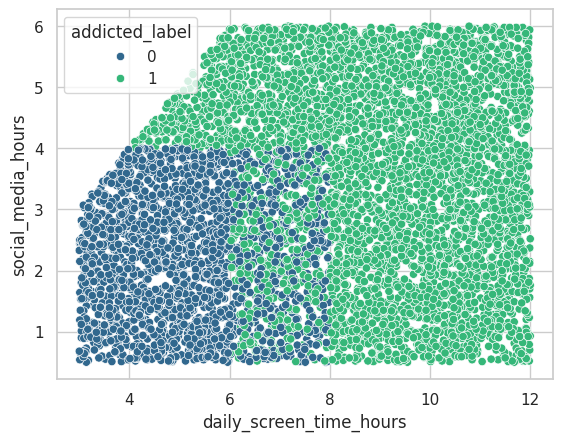

In [23]:
sns.scatterplot(df, x="daily_screen_time_hours", y="social_media_hours", hue="addicted_label", palette='viridis')

# Experimentos

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns

In [25]:
# Converting categorical columns to categorical data type future usage in the metodoly pipeline
display(df.dtypes)
for column in ["stress_level", "academic_work_impact"]:
    df[column] = df[column].astype("category")
display(df.dtypes)

age                                       int64
daily_screen_time_hours                 float64
social_media_hours                      float64
gaming_hours                            float64
work_study_hours                        float64
sleep_hours                             float64
notifications_per_day                     int64
app_opens_per_day                         int64
stress_level                           category
academic_work_impact                   category
addicted_label                            int64
screen_time_to_social_network_ratio     float64
dtype: object

age                                       int64
daily_screen_time_hours                 float64
social_media_hours                      float64
gaming_hours                            float64
work_study_hours                        float64
sleep_hours                             float64
notifications_per_day                     int64
app_opens_per_day                         int64
stress_level                           category
academic_work_impact                   category
addicted_label                            int64
screen_time_to_social_network_ratio     float64
dtype: object

## Training and validation

### Splitting Training and Test Data

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [27]:
targets = df["addicted_label"]

features_df = df.drop(columns=["addicted_label"])

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(features_df, targets, test_size=.2, random_state=42)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(addicted_label
 1    0.685253
 0    0.314747
 Name: proportion, dtype: float64,
 addicted_label
 1    0.70066
 0    0.29934
 Name: proportion, dtype: float64)

## Definindo um pipeline base de transformação de features

In [29]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Logistic Regression

In [30]:
cv = StratifiedKFold(5) #, shuffle=True, random_state=42)

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__solver": ["liblinear", "lbfgs"]
}

grid_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

grid = RandomizedSearchCV(
    estimator=grid_model,
    param_distributions=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid.fit(X_train, y_train)

/home/melo/code/data-science/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__C': [0.01, 0.1, ...], 'clf__solver': ['liblinear', 'lbfgs']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-

In [31]:
print("Melhores parâmetros:", grid.best_params_)
print("Melhor F1 médio em CV:", round(grid.best_score_, 4))

display(pd.DataFrame(grid.cv_results_))

Melhores parâmetros: {'clf__solver': 'liblinear', 'clf__C': 10.0}
Melhor F1 médio em CV: 0.9391


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__solver,param_clf__C,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.031045,0.003555,0.013659,0.001482,liblinear,0.01,"{'clf__solver': 'liblinear', 'clf__C': 0.01}",0.931743,0.939293,0.931561,...,0.931661,0.004268,8,0.931333,0.930535,0.933200,0.933511,0.933711,0.932458,0.001280
1,0.025412,0.006178,0.011264,0.003189,lbfgs,0.01,"{'clf__solver': 'lbfgs', 'clf__C': 0.01}",0.930809,0.938856,0.932281,...,0.932140,0.003713,7,0.933553,0.932326,0.934407,0.933114,0.934779,0.933636,0.000883
2,0.027651,0.006852,0.010229,0.002513,liblinear,0.10,"{'clf__solver': 'liblinear', 'clf__C': 0.1}",0.937831,0.940627,0.934840,...,0.934746,0.004550,5,0.933777,0.934287,0.935979,0.937832,0.937968,0.935969,0.001738
3,0.026794,0.004274,0.012618,0.003064,lbfgs,0.10,"{'clf__solver': 'lbfgs', 'clf__C': 0.1}",0.936592,0.939454,0.937666,...,0.934498,0.004918,6,0.933577,0.934108,0.934840,0.936784,0.937407,0.935343,0.001499
4,0.029672,0.001796,0.011239,0.000875,liblinear,1.00,"{'clf__solver': 'liblinear', 'clf__C': 1.0}",0.941099,0.943296,0.939695,...,0.938259,0.004717,3,0.936511,0.937354,0.939157,0.940569,0.939434,0.938605,0.001470
5,0.028105,0.002736,0.012345,0.001801,lbfgs,1.00,"{'clf__solver': 'lbfgs', 'clf__C': 1.0}",0.940397,0.943296,0.939073,...,0.937994,0.004605,4,0.936397,0.937375,0.938667,0.940609,0.939434,0.938496,0.001486
6,0.029815,0.001984,0.011272,0.000432,liblinear,10.00,"{'clf__solver': 'liblinear', 'clf__C': 10.0}",0.940397,0.944556,0.939153,...,0.939065,0.004781,1,0.937906,0.938748,0.940686,0.942919,0.940256,0.940103,0.001730
7,0.026130,0.008162,0.008731,0.000890,lbfgs,10.00,"{'clf__solver': 'lbfgs', 'clf__C': 10.0}",0.940397,0.944556,0.939153,...,0.939065,0.004781,1,0.937906,0.938925,0.940686,0.942919,0.940256,0.940138,0.001703


In [32]:
best_reg = grid.best_estimator_

y_pred_best = best_reg.predict(X_test)
y_prob_best = best_reg.predict_proba(X_test)[:, 1]

print("Accuracy         :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision        :", round(precision_score(y_test, y_pred_best), 4))
print("Recall           :", round(recall_score(y_test, y_pred_best), 4))
print("F1-score         :", round(f1_score(y_test, y_pred_best), 4))
print("ROC-AUC          :", round(roc_auc_score(y_test, y_prob_best), 4))

Accuracy         : 0.9259
Precision        : 0.9485
Recall           : 0.9455
F1-score         : 0.947
ROC-AUC          : 0.9759


## Random Forest

In [33]:
param_grid = {
    'clf__n_estimators': [100, 200, 300],      # Number of trees in the forest
    'clf__max_depth': [None, 10, 20, 30],      # Maximum depth of the tree
    'clf__max_features': ['sqrt', 'log2'],     # Number of features for best split
    'clf__criterion': ['gini', 'entropy']      # Method used to measure the quality of a split
}

grid_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier())
])

grid = RandomizedSearchCV(
    estimator=grid_model,
    param_distributions=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__criterion': ['gini', 'entropy'], 'clf__max_depth': [None, 10, ...], 'clf__max_features': ['sqrt', 'log2'], 'clf__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

In [34]:
print("Melhores parâmetros:", grid.best_params_)
print("Melhor F1 médio em CV:", round(grid.best_score_, 4))

grid_results = pd.DataFrame(grid.cv_results_)
cols = [
    "param_clf__max_depth",
    "param_clf__n_estimators",
    "param_clf__max_features",
    "param_clf__criterion",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "rank_test_score"
]

display(grid_results[cols].sort_values("rank_test_score"))

Melhores parâmetros: {'clf__n_estimators': 200, 'clf__max_features': 'sqrt', 'clf__max_depth': None, 'clf__criterion': 'gini'}
Melhor F1 médio em CV: 0.9483


,param_clf__max_depth,param_clf__n_estimators,param_clf__max_features,param_clf__criterion,mean_test_score,std_test_score,mean_train_score,rank_test_score
7,None,200,sqrt,gini,0.948291,0.005838,1.000000,1
4,10,300,sqrt,entropy,0.947942,0.006900,0.985421,2
0,20,300,log2,entropy,0.947753,0.006736,1.000000,3
6,20,200,log2,gini,0.947120,0.007629,1.000000,4
5,30,100,sqrt,gini,0.946601,0.006124,1.000000,5
1,30,300,log2,entropy,0.946534,0.006420,1.000000,6
2,20,300,sqrt,gini,0.946234,0.005191,1.000000,7
8,20,200,sqrt,entropy,0.946103,0.006513,1.000000,8
3,20,100,log2,entropy,0.946047,0.004321,1.000000,9
9,10,200,sqrt,gini,0.945869,0.006396,0.994909,10


In [35]:
best_frt = grid.best_estimator_

y_pred_best = best_frt.predict(X_test)
y_prob_best = best_frt.predict_proba(X_test)[:, 1]

print("Accuracy         :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision        :", round(precision_score(y_test, y_pred_best), 4))
print("Recall           :", round(recall_score(y_test, y_pred_best), 4))
print("F1-score         :", round(f1_score(y_test, y_pred_best), 4))
print("ROC-AUC          :", round(roc_auc_score(y_test, y_prob_best), 4))

Accuracy         : 0.9354
Precision        : 0.9607
Recall           : 0.9466
F1-score         : 0.9536
ROC-AUC          : 0.9884


## Comparing the two models

In [36]:
from scipy import stats
from sklearn.model_selection import cross_validate
from sklearn.metrics import RocCurveDisplay

In [43]:
def paired_ttest(n=20, fold_size=10):
    t_stats = []
    p_values = []
    model_a_scores = []
    model_b_scores = []

    for _ in range(n):
        cv_statistical_test = StratifiedKFold(n_splits=fold_size)  #, shuffle=True, random_state=0)

        res_modelo_a = cross_validate(best_reg, features_df, targets, cv=cv_statistical_test, scoring='f1')
        scores_a = res_modelo_a['test_score']

        res_modelo_b = cross_validate(best_frt, features_df, targets, cv=cv_statistical_test, scoring='f1')
        scores_b = res_modelo_b['test_score']

        # paired ttest to validate if the models performance is statisticaly different from each other
        t_stat, p_value = stats.ttest_rel(scores_a, scores_b)
        
        t_stats.append(t_stat)
        p_values.append(p_value)
        
        model_a_scores.append(scores_a.mean())
        model_b_scores.append(scores_b.mean())
    
    return np.array(t_stats).mean(), np.array(p_values).mean(), np.array(model_a_scores).mean(), np.array(model_b_scores).mean()

In [44]:
t_stat, p_value, scores_a, scores_b = paired_ttest()

reject = "Reject the null hypotesis" if p_value < 0.05 else "Dont reject the null hypotesis"

print(f"Linear Regression: {scores_a:.4f}")
print(f"Random Forest: {scores_b:.4f}")
print(f"P-Valor: {p_value:.4f} {reject}")
print(f"T-Stat: {t_stat:.4f}")

Linear Regression: 0.9415
Random Forest: 0.9464
P-Valor: 0.0618 Dont reject the null hypotesis
T-Stat: -2.2753


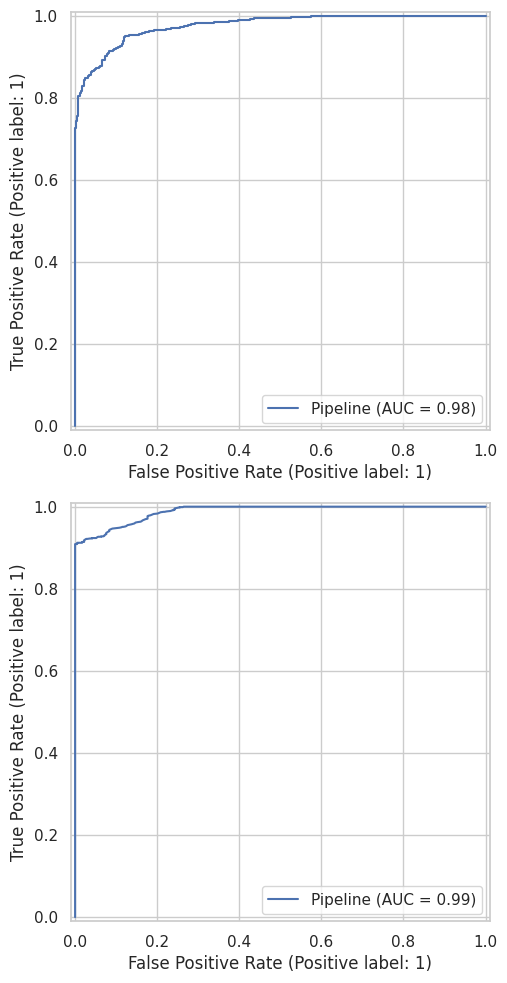

In [39]:
f, axes = plt.subplots(2, 1, figsize=(9, 10))

#axes[0].set_title("ROC-AUC")

RocCurveDisplay.from_estimator(best_reg, X_test, y_test, ax=axes[0])
RocCurveDisplay.from_estimator(best_frt, X_test, y_test, ax=axes[1])

plt.tight_layout()

In [40]:
df_importance = pd.DataFrame([{"feature_name": name, "importance": imp} for imp, name in zip(best_frt["clf"].feature_importances_, X_train.columns)])

df_importance = df_importance.sort_values(by="importance", ascending=False)

df_importance

,feature_name,importance
1,daily_screen_time_hours,0.567307
2,social_media_hours,0.196302
8,stress_level,0.096365
4,work_study_hours,0.023208
5,sleep_hours,0.022713
6,notifications_per_day,0.022511
3,gaming_hours,0.022233
7,app_opens_per_day,0.021093
0,age,0.016317
10,screen_time_to_social_network_ratio,0.003016


/tmp/ipykernel_17061/1139683284.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_importance, x="importance", y="feature_name", palette="viridis")


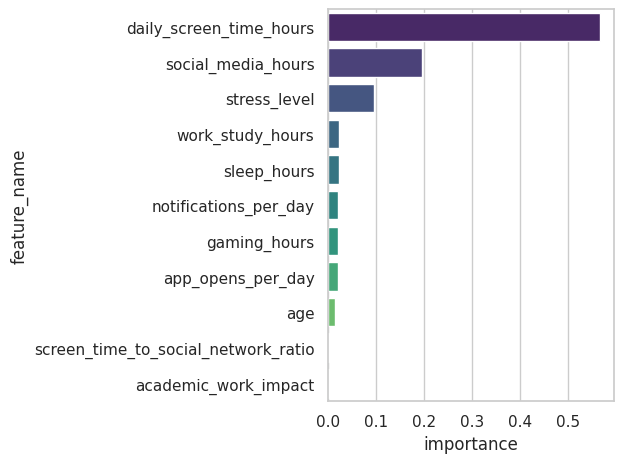

In [41]:
ax = sns.barplot(data=df_importance, x="importance", y="feature_name", palette="viridis")

#ax.title.set_text(best_frt["clf"].__class__.__name__)
plt.tight_layout()
plt.show()

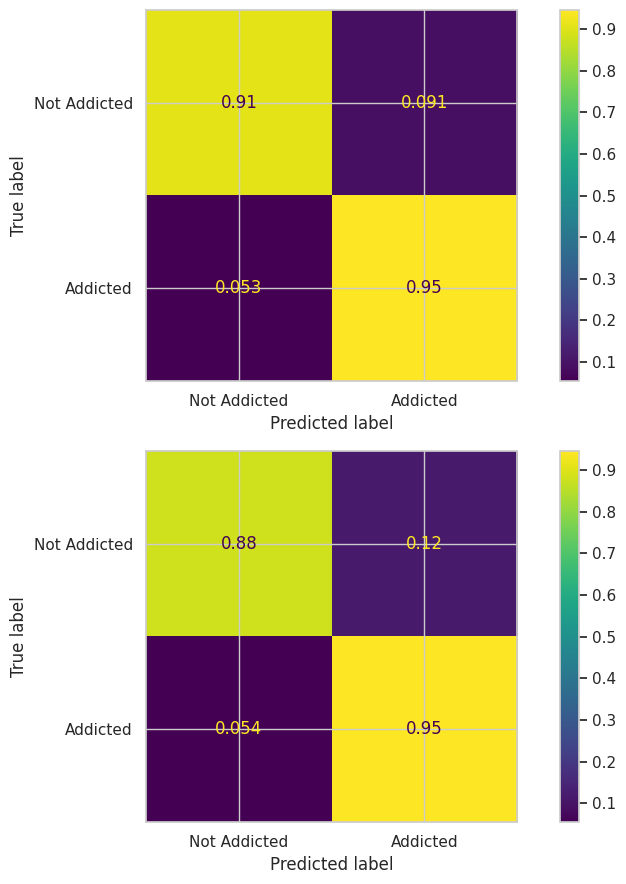

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt

f, axes = plt.subplots(2, 1, figsize=(9,9))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, best_frt.predict(X_test), normalize='true'), 
    display_labels=["Not Addicted", "Addicted"]
    ).plot(ax=axes[0], cmap="viridis",)
#axes[0].title.set_text(best_frt["clf"].__class__.__name__)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, best_reg.predict(X_test), normalize='true'), 
    display_labels=["Not Addicted", "Addicted"],
    ).plot(ax=axes[1], cmap="viridis")
#axes[1].title.set_text(best_reg["clf"].__class__.__name__)

plt.tight_layout()